# 🗳️ ElectioAnalytics — Projections 2027
## Prédiction des tendances électorales — Département du Nord (59)

**Modèle utilisé :** Régression Logistique Version B (socio-éco pur)  
**Données :** Extrapolation des tendances 2016→2021 vers 2026  
**Scénarios :** Pessimiste / Neutre / Optimiste

In [5]:
import warnings
warnings.filterwarnings('ignore')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ── Chemins ──────────────────────────────────────────────────────────────────
BASE       = Path('../')
FINAL_PATH = BASE / 'data/final'
MODEL_PATH = BASE / 'data/models'
FIG_PATH   = MODEL_PATH / 'figures'
FIG_PATH.mkdir(parents=True, exist_ok=True)

# ── Palette ──────────────────────────────────────────────────────────────────
PALETTE = {
    'DROITE':    '#E63946',
    'CENTRE':    '#457B9D',
    'EXCEPTION': '#457B9D',
    'GAUCHE':    '#E76F51',
    'accent':    '#1D3557',
    'gray':      '#6C757D',
}

plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
})

print('✅ Imports OK')

✅ Imports OK


## 1. Chargement du modèle et des données

In [6]:
# ── Charger les données ───────────────────────────────────────────────────────
train = pd.read_csv(FINAL_PATH / 'ml_train_2017_vB.csv')
test  = pd.read_csv(FINAL_PATH / 'ml_test_2022_vB.csv')
df_full = pd.read_csv(FINAL_PATH / 'dataset_ml_final.csv',
                      dtype={'code_geo': str})

FEATURES_B = [
    'revenu_median_scaled',
    'taux_faible_diplome_scaled',
    'pct_abstention_scaled',
    'log_delinquance_scaled',
    'log_population_scaled',
]

FEATURES_RAW = [
    'revenu_median',
    'taux_faible_diplome',
    'pct_abstention',
    'taux_delinquance',
    'population_municipale',
]

# ── Re-créer le scaler depuis les données 2017 ───────────────────────────────
# (évite le problème de compatibilité pickle)
df_2017_raw = df_full[df_full['annee'] == 2017][FEATURES_RAW].copy()
df_2017_raw['log_population']  = np.log1p(df_2017_raw['population_municipale'])
df_2017_raw['log_delinquance'] = np.log1p(np.clip(
    df_2017_raw['taux_delinquance'],
    0,
    df_2017_raw['taux_delinquance'].quantile(0.95)
))

cols_to_scale = [
    'revenu_median', 'taux_faible_diplome',
    'pct_abstention', 'log_delinquance', 'log_population'
]

scaler = StandardScaler()
scaler.fit(df_2017_raw[cols_to_scale])
print('✅ Scaler re-créé depuis les données 2017')

# ── Re-entraîner le modèle binaire ───────────────────────────────────────────
X_train = train[FEATURES_B].values
y_train = (train['bloc_vainqueur'] != 'DROITE').astype(int).values

model = LogisticRegression(
    C=0.1,
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
model.fit(X_train, y_train)

# Vérification sur test
X_test = test[FEATURES_B].values
y_test = (test['bloc_vainqueur'] != 'DROITE').astype(int).values
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, model.predict(X_test))
print(f'✅ Modèle re-entraîné : {type(model).__name__}')
print(f'   Accuracy test 2022 : {acc:.3f} (doit être ~0.887)')
print(f'   Train : {len(X_train)} communes | Test : {len(X_test)} communes')

✅ Scaler re-créé depuis les données 2017
✅ Modèle re-entraîné : LogisticRegression
   Accuracy test 2022 : 0.887 (doit être ~0.887)
   Train : 648 communes | Test : 648 communes


## 2. Construction des données 2026 (extrapolation)

In [7]:
# ── Données 2016 et 2021 par commune ────────────────────────────────────────
df_2016 = df_full[df_full['annee'] == 2017][['code_geo', 'libelle_commune'] + FEATURES_RAW].copy()
df_2021 = df_full[df_full['annee'] == 2022][['code_geo', 'libelle_commune'] + FEATURES_RAW].copy()

df_2016 = df_2016.set_index('code_geo')
df_2021 = df_2021.set_index('code_geo')

# ── Tendance annuelle (2016→2021 = 5 ans) ───────────────────────────────────
# delta_annuel = (valeur_2021 - valeur_2016) / 5
delta = (df_2021[FEATURES_RAW] - df_2016[FEATURES_RAW]) / 5

# ── Projection 2026 = 2021 + 5 ans de tendance ──────────────────────────────
df_2026_neutre = df_2021[FEATURES_RAW] + delta * 5

# ── Scénario Pessimiste : dégradation de 10% supplémentaire ─────────────────
# (chômage +10%, revenu -10%, délinquance +10%, faible diplôme +5%)
df_2026_pessimiste = df_2026_neutre.copy()
df_2026_pessimiste['taux_delinquance']    *= 1.10
df_2026_pessimiste['revenu_median']       *= 0.90
df_2026_pessimiste['taux_faible_diplome'] *= 1.05
df_2026_pessimiste['pct_abstention']      *= 1.05

# ── Scénario Optimiste : amélioration de 10% ────────────────────────────────
df_2026_optimiste = df_2026_neutre.copy()
df_2026_optimiste['taux_delinquance']    *= 0.90
df_2026_optimiste['revenu_median']       *= 1.10
df_2026_optimiste['taux_faible_diplome'] *= 0.95
df_2026_optimiste['pct_abstention']      *= 0.95

# ── Ajouter population (stable) ─────────────────────────────────────────────
for df in [df_2026_neutre, df_2026_pessimiste, df_2026_optimiste]:
    df['population_municipale'] = df_2021['population_municipale']

print('✅ Données 2026 construites')
print(f'   Scénarios : Neutre / Pessimiste / Optimiste')
print(f'   Communes  : {len(df_2026_neutre)}')

# Aperçu
print('\n🔍 Comparaison moyennes départementales :')
print(f"{'Feature':<30} {'2016':>10} {'2021':>10} {'2026 Neutre':>12}")
print('-' * 65)
for feat in FEATURES_RAW:
    v16 = df_2016[feat].mean()
    v21 = df_2021[feat].mean()
    v26 = df_2026_neutre[feat].mean()
    print(f"{feat:<30} {v16:>10.2f} {v21:>10.2f} {v26:>12.2f}")

✅ Données 2026 construites
   Scénarios : Neutre / Pessimiste / Optimiste
   Communes  : 648

🔍 Comparaison moyennes départementales :
Feature                              2016       2021  2026 Neutre
-----------------------------------------------------------------
revenu_median                    20919.65   23276.28     25632.91
taux_faible_diplome                 55.67      55.17        54.66
pct_abstention                      18.22      23.58        28.94
taux_delinquance                    15.63      14.52        13.40
population_municipale             4029.77    4029.77      4029.77


## 3. Preprocessing et prédiction 2027

In [8]:
import numpy as np

def preparer_features(df_raw, scaler, features_raw, features_scaled):
    """Applique les mêmes transformations que preprocessing.py."""
    df = df_raw[features_raw].copy()
    
    # Log-transform population et délinquance (comme dans preprocessing.py)
    df['log_population']  = np.log1p(df['population_municipale'])
    df['log_delinquance'] = np.log1p(np.clip(
        df['taux_delinquance'],
        0,
        df['taux_delinquance'].quantile(0.95)
    ))
    
    # Features à scaler
    cols_to_scale = [
        'revenu_median', 'taux_faible_diplome',
        'pct_abstention', 'log_delinquance', 'log_population'
    ]
    
    # Appliquer le scaler (fitté sur 2017)
    scaled = scaler.transform(df[cols_to_scale])
    
    df_scaled = pd.DataFrame(scaled, columns=features_scaled, index=df.index)
    return df_scaled

# Préparer les 3 scénarios
scenarios = {
    'Neutre':      df_2026_neutre,
    'Pessimiste':  df_2026_pessimiste,
    'Optimiste':   df_2026_optimiste,
}

resultats = {}

for nom, df_scenario in scenarios.items():
    X = preparer_features(df_scenario, scaler, FEATURES_RAW, FEATURES_B)
    
    # Prédiction binaire + probabilités
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)
    
    df_result = pd.DataFrame({
        'code_geo':        df_scenario.index,
        'libelle_commune': df_2021.loc[df_scenario.index, 'libelle_commune'] if 'libelle_commune' in df_2021.columns else df_scenario.index,
        'pred_binaire':    y_pred,          # 0=DROITE, 1=EXCEPTION
        'proba_droite':    y_proba[:, 0],
        'proba_exception': y_proba[:, 1],
        'pred_label':      ['EXCEPTION' if p == 1 else 'DROITE' for p in y_pred],
        'scenario':        nom,
    })
    resultats[nom] = df_result
    
    n_except = y_pred.sum()
    print(f'  {nom:<15} → DROITE: {(y_pred==0).sum()}  EXCEPTION: {n_except}  ({n_except/len(y_pred)*100:.1f}%)')

# Résultats réels 2022 pour comparaison
df_2022_reel = df_full[df_full['annee'] == 2022][['code_geo', 'libelle_commune', 'bloc_vainqueur']].set_index('code_geo')
n_except_2022 = (df_2022_reel['bloc_vainqueur'] != 'DROITE').sum()
print(f'  {"Réel 2022":<15} → DROITE: {(df_2022_reel["bloc_vainqueur"]=="DROITE").sum()}  EXCEPTION: {n_except_2022}  ({n_except_2022/len(df_2022_reel)*100:.1f}%)')
print(f'  {"Réel 2017":<15} → DROITE: 598  EXCEPTION: 50  (7.7%)')

  Neutre          → DROITE: 463  EXCEPTION: 185  (28.5%)
  Pessimiste      → DROITE: 425  EXCEPTION: 223  (34.4%)
  Optimiste       → DROITE: 506  EXCEPTION: 142  (21.9%)
  Réel 2022       → DROITE: 470  EXCEPTION: 178  (27.5%)
  Réel 2017       → DROITE: 598  EXCEPTION: 50  (7.7%)


## 4. Figure 1 — Évolution temporelle des blocs (2017→2022→2027)

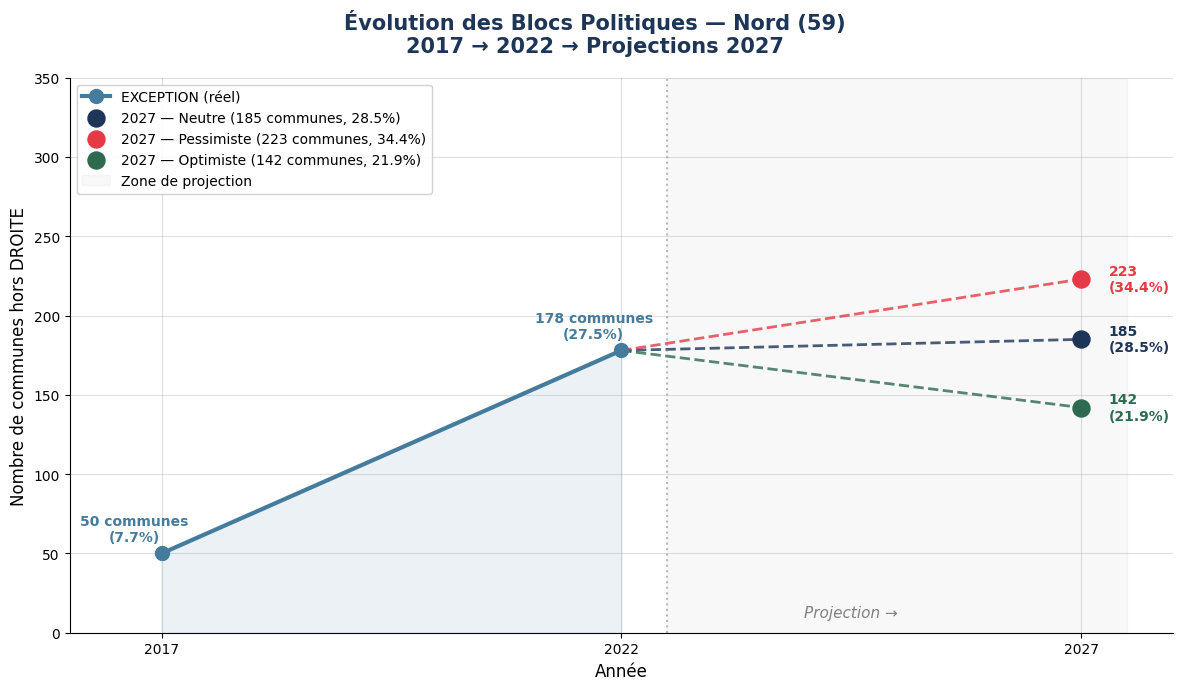

✅ Figure 09 sauvegardée


In [10]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('Évolution des Blocs Politiques — Nord (59)\n2017 → 2022 → Projections 2027',
             fontsize=15, fontweight='bold', color=PALETTE['accent'])

annees_hist = [2017, 2022]
droite_hist = [598, 470]
except_hist = [50, 178]

# Projections 2027
proj_annee = 2027
couleurs_scenarios = {
    'Pessimiste': '#E63946',
    'Neutre':     '#1D3557',
    'Optimiste':  '#2D6A4F',
}

# Courbe historique EXCEPTION
ax.plot(annees_hist, except_hist, 'o-',
        color=PALETTE['CENTRE'], lw=3, ms=10,
        label='EXCEPTION (réel)', zorder=5)

# Remplir entre les points historiques
ax.fill_between(annees_hist, except_hist, alpha=0.1, color=PALETTE['CENTRE'])

# Points 2027 par scénario
for nom, df_res in resultats.items():
    n_except = df_res['pred_binaire'].sum()
    color = couleurs_scenarios[nom]
    
    # Ligne pointillée 2022→2027
    ax.plot([2022, 2027], [178, n_except], '--',
            color=color, lw=2, alpha=0.8)
    ax.scatter(2027, n_except, s=150, color=color, zorder=6,
               label=f'2027 — {nom} ({n_except} communes, {n_except/648*100:.1f}%)')
    ax.annotate(f'{n_except}\n({n_except/648*100:.1f}%)',
                xy=(2027, n_except), xytext=(2027.3, n_except),
                fontsize=10, color=color, fontweight='bold',
                va='center')

# Annotations historiques
for x, y in zip(annees_hist, except_hist):
    ax.annotate(f'{y} communes\n({y/648*100:.1f}%)',
                xy=(x, y), xytext=(x - 0.3, y + 8),
                fontsize=10, color=PALETTE['CENTRE'], fontweight='bold',
                ha='center')

# Zone de projection
ax.axvspan(2022.5, 2027.5, alpha=0.05, color='gray', label='Zone de projection')
ax.axvline(x=2022.5, color='gray', linestyle=':', alpha=0.5, lw=1.5)
ax.text(2024.5, 10, 'Projection →', ha='center', fontsize=11,
        color='gray', style='italic')

ax.set_xlabel('Année', fontsize=12)
ax.set_ylabel('Nombre de communes hors DROITE', fontsize=12)
ax.set_xlim(2016, 2028)
ax.set_ylim(0, 350)
ax.set_xticks([2017, 2022, 2027])
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig(FIG_PATH / '09_evolution_temporelle_2027.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 09 sauvegardée')

## 5. Figure 2 — Probabilités de bascule par commune (Top 30)

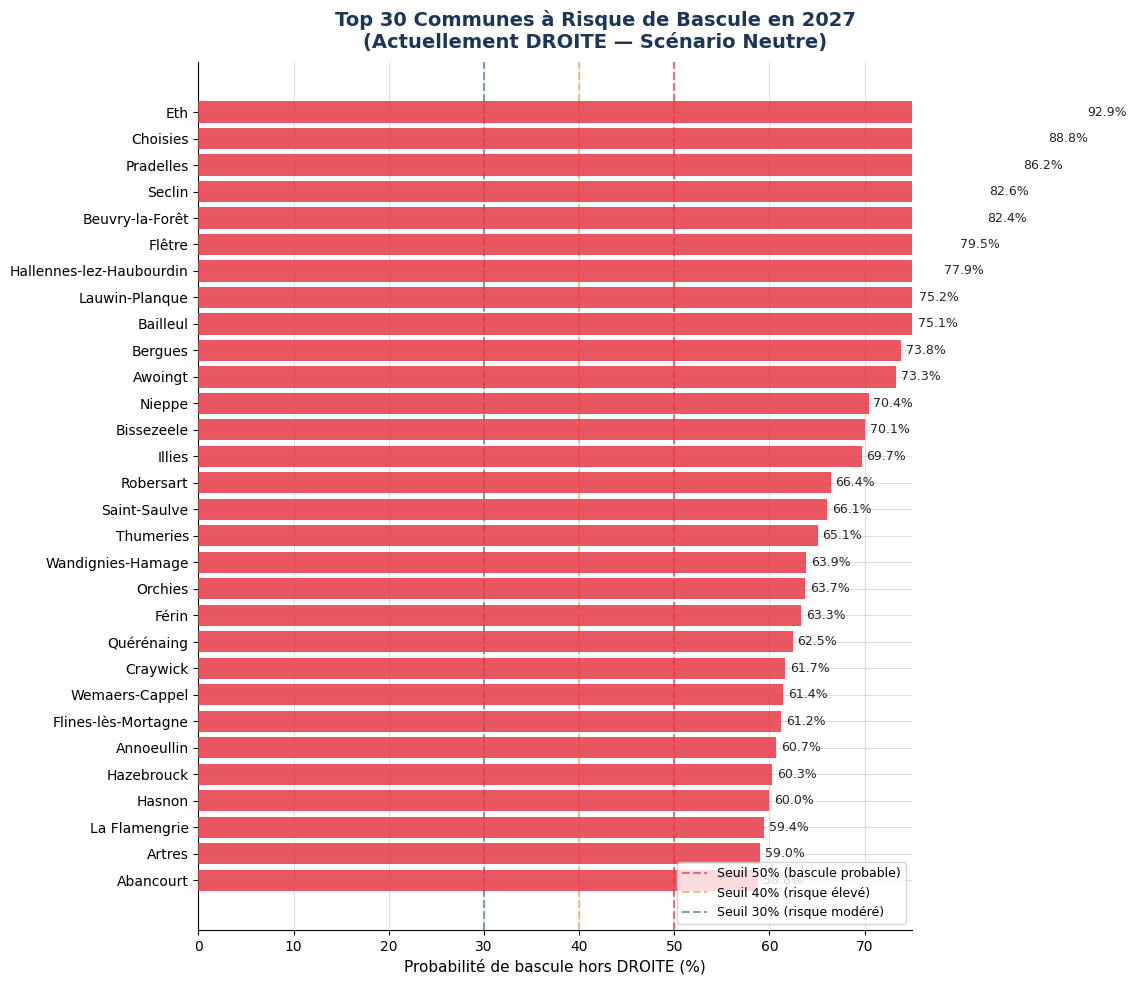

✅ Figure 10 sauvegardée — 30 communes à risque identifiées


In [11]:
# Scénario neutre — communes triées par probabilité d'exception
df_neutre = resultats['Neutre'].copy()

# Ajouter résultat réel 2022
df_neutre = df_neutre.set_index('code_geo')
df_neutre['reel_2022'] = df_2022_reel['bloc_vainqueur']
df_neutre['reel_2017'] = df_full[df_full['annee']==2017].set_index('code_geo')['bloc_vainqueur']

# Communes actuellement DROITE en 2022 avec forte proba d'exception en 2027
# = communes à risque de bascule
df_risque = df_neutre[
    (df_neutre['reel_2022'] == 'DROITE') &
    (df_neutre['proba_exception'] >= 0.30)
].sort_values('proba_exception', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('Top 30 Communes à Risque de Bascule en 2027\n(Actuellement DROITE — Scénario Neutre)',
             fontsize=14, fontweight='bold', color=PALETTE['accent'])

# Couleur selon seuil
colors = ['#E63946' if p >= 0.5 else '#F4A261' if p >= 0.4 else '#457B9D'
          for p in df_risque['proba_exception']]

bars = ax.barh(range(len(df_risque)),
               df_risque['proba_exception'] * 100,
               color=colors, alpha=0.85, zorder=3)

# Labels
communes = df_risque.index.tolist()
# Récupérer les noms
noms = []
for code in communes:
    nom = df_full[df_full['code_geo']==code]['libelle_commune'].values
    noms.append(nom[0] if len(nom) > 0 else code)

ax.set_yticks(range(len(df_risque)))
ax.set_yticklabels(noms, fontsize=10)
ax.set_xlabel('Probabilité de bascule hors DROITE (%)', fontsize=11)

# Valeurs sur les barres
for i, (bar, p) in enumerate(zip(bars, df_risque['proba_exception'])):
    ax.text(p * 100 + 0.5, i, f'{p*100:.1f}%',
            va='center', fontsize=9, color='#212529')

# Lignes de seuil
ax.axvline(x=50, color='#E63946', linestyle='--', alpha=0.7, lw=1.5,
           label='Seuil 50% (bascule probable)')
ax.axvline(x=40, color='#F4A261', linestyle='--', alpha=0.7, lw=1.5,
           label='Seuil 40% (risque élevé)')
ax.axvline(x=30, color='#457B9D', linestyle='--', alpha=0.7, lw=1.5,
           label='Seuil 30% (risque modéré)')

ax.set_xlim(0, 75)
ax.legend(loc='lower right', fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIG_PATH / '10_communes_risque_bascule_2027.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Figure 10 sauvegardée — {len(df_risque)} communes à risque identifiées')

## 6. Figure 3 — Comparaison des 3 scénarios

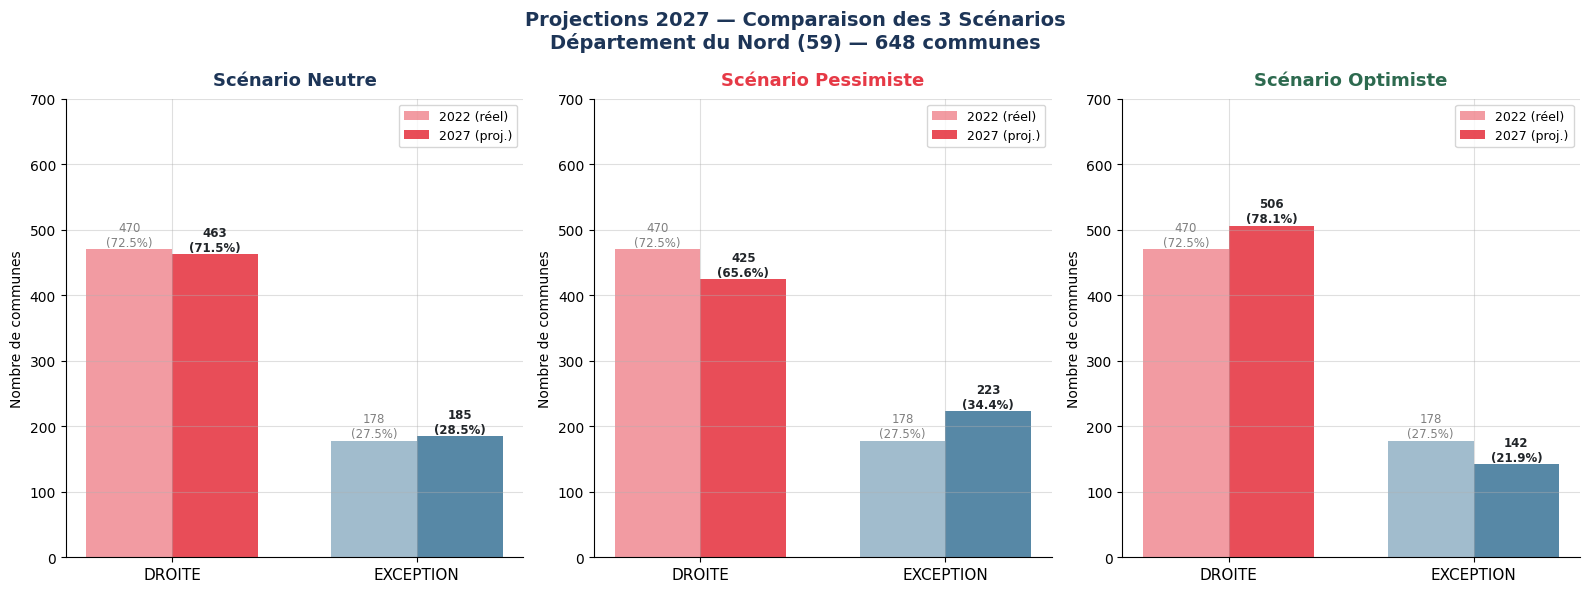

✅ Figure 11 sauvegardée


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Projections 2027 — Comparaison des 3 Scénarios\nDépartement du Nord (59) — 648 communes',
             fontsize=14, fontweight='bold', color=PALETTE['accent'])

for ax, (nom, df_res) in zip(axes, resultats.items()):
    n_droite  = (df_res['pred_binaire'] == 0).sum()
    n_except  = (df_res['pred_binaire'] == 1).sum()
    
    # Comparer avec 2022 réel
    labels  = ['DROITE', 'EXCEPTION']
    vals    = [n_droite, n_except]
    vals_22 = [470, 178]
    
    x = np.arange(2)
    w = 0.35
    
    bars1 = ax.bar(x - w/2, vals_22, w,
                   color=['#E63946', '#457B9D'], alpha=0.5,
                   label='2022 (réel)')
    bars2 = ax.bar(x + w/2, vals, w,
                   color=['#E63946', '#457B9D'], alpha=0.9,
                   label='2027 (proj.)')
    
    for bar, v in zip(bars1, vals_22):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{v}\n({v/648*100:.1f}%)', ha='center', fontsize=8.5, color='gray')
    for bar, v in zip(bars2, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{v}\n({v/648*100:.1f}%)', ha='center', fontsize=8.5,
                color='#212529', fontweight='bold')
    
    couleur_titre = couleurs_scenarios[nom]
    ax.set_title(f'Scénario {nom}', fontsize=13, fontweight='bold',
                 color=couleur_titre, pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylim(0, 700)
    ax.set_ylabel('Nombre de communes', fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_PATH / '11_comparaison_scenarios_2027.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 11 sauvegardée')

## 7. Figure 4 — Distribution des probabilités de bascule

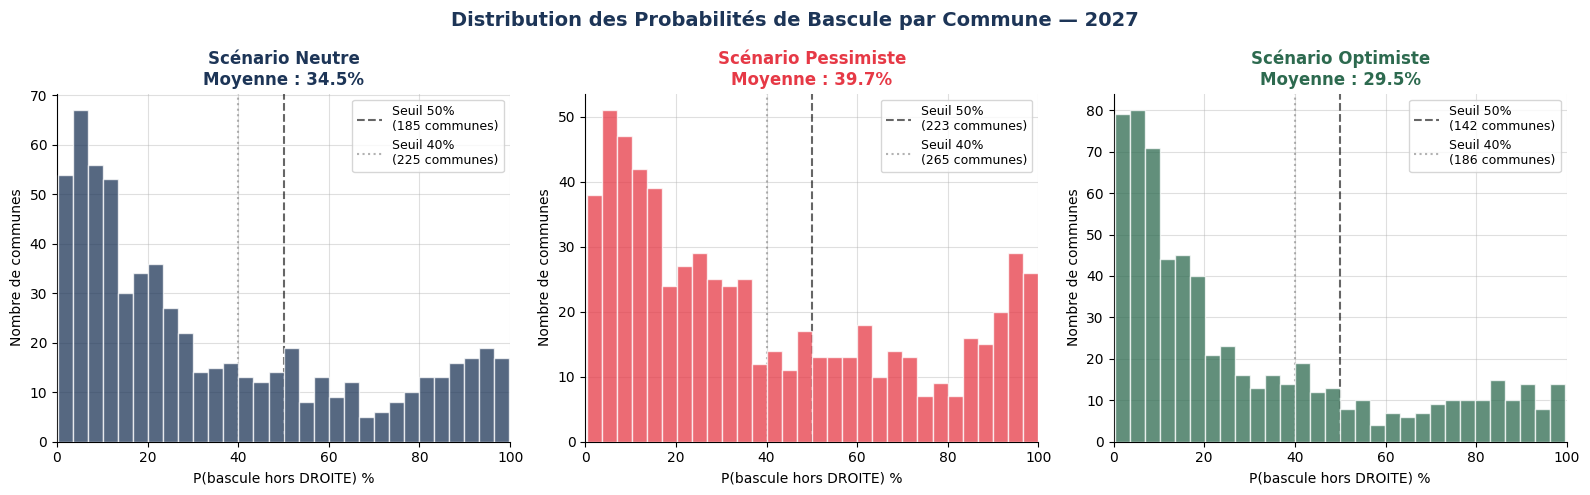

✅ Figure 12 sauvegardée


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribution des Probabilités de Bascule par Commune — 2027',
             fontsize=14, fontweight='bold', color=PALETTE['accent'])

for ax, (nom, df_res) in zip(axes, resultats.items()):
    proba = df_res['proba_exception'] * 100
    
    # Histogramme
    ax.hist(proba, bins=30, color=couleurs_scenarios[nom],
            alpha=0.75, edgecolor='white', zorder=3)
    
    # Lignes de seuil
    ax.axvline(x=50, color='black', linestyle='--', alpha=0.6, lw=1.5,
               label=f'Seuil 50%\n({(proba>=50).sum()} communes)')
    ax.axvline(x=40, color='gray', linestyle=':', alpha=0.6, lw=1.5,
               label=f'Seuil 40%\n({(proba>=40).sum()} communes)')
    
    ax.set_title(f'Scénario {nom}\nMoyenne : {proba.mean():.1f}%',
                 fontsize=12, fontweight='bold', color=couleurs_scenarios[nom])
    ax.set_xlabel('P(bascule hors DROITE) %', fontsize=10)
    ax.set_ylabel('Nombre de communes', fontsize=10)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig(FIG_PATH / '12_distribution_probabilites_2027.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 12 sauvegardée')

## 8. Tableau récapitulatif des projections

In [14]:
print('=' * 65)
print('  RÉSUMÉ DES PROJECTIONS 2027 — DÉPARTEMENT DU NORD (59)')
print('=' * 65)
print(f"{'':30} {'DROITE':>8} {'EXCEPTION':>10} {'% Except':>10}")
print('-' * 65)
print(f"{'Réel 2017':30} {'598':>8} {'50':>10} {'7.7%':>10}")
print(f"{'Réel 2022':30} {'470':>8} {'178':>10} {'27.5%':>10}")
print('-' * 65)
for nom, df_res in resultats.items():
    n_d = (df_res['pred_binaire'] == 0).sum()
    n_e = (df_res['pred_binaire'] == 1).sum()
    pct = n_e / 648 * 100
    print(f"{'Projection 2027 — '+nom:<30} {n_d:>8} {n_e:>10} {pct:>9.1f}%")
print('=' * 65)

# Communes identifiées à risque dans tous les scénarios
risque_commun = None
for nom, df_res in resultats.items():
    communes_except = set(df_res[df_res['pred_binaire']==1]['code_geo'])
    if risque_commun is None:
        risque_commun = communes_except
    else:
        risque_commun &= communes_except

print(f'\n✅ Communes à risque dans LES 3 SCÉNARIOS : {len(risque_commun)}')
print('   (Ces communes basculeront hors DROITE dans tous les cas)')

# Afficher les 10 premières
noms_communs = []
for code in list(risque_commun)[:10]:
    nom_c = df_full[df_full['code_geo']==code]['libelle_commune'].values
    if len(nom_c) > 0:
        noms_communs.append(nom_c[0])
print(f'   Exemples : {", ".join(noms_communs[:10])}')

  RÉSUMÉ DES PROJECTIONS 2027 — DÉPARTEMENT DU NORD (59)
                                 DROITE  EXCEPTION   % Except
-----------------------------------------------------------------
Réel 2017                           598         50       7.7%
Réel 2022                           470        178      27.5%
-----------------------------------------------------------------
Projection 2027 — Neutre            463        185      28.5%
Projection 2027 — Pessimiste        425        223      34.4%
Projection 2027 — Optimiste         506        142      21.9%

✅ Communes à risque dans LES 3 SCÉNARIOS : 142
   (Ces communes basculeront hors DROITE dans tous les cas)
   Exemples : Gruson, Orchies, Estreux, Santes, Lesquin, Wambrechies, Houplin-Ancoisne, Sainghin-en-Weppes, Lille, Vendeville


## 9. Export des résultats

In [15]:
# Consolider tous les scénarios
df_export = pd.concat(resultats.values(), ignore_index=True)

# Ajouter données réelles pour comparaison
df_export_path = FINAL_PATH / 'projections_2027.csv'
df_export.to_csv(df_export_path, index=False, encoding='utf-8')
print(f'✅ Projections exportées → {df_export_path}')
print(f'   {len(df_export)} lignes (648 communes × 3 scénarios)')
print('\n📊 Figures générées :')
for i, name in enumerate(['09_evolution_temporelle_2027.png',
                           '10_communes_risque_bascule_2027.png',
                           '11_comparaison_scenarios_2027.png',
                           '12_distribution_probabilites_2027.png'], 9):
    print(f'   → data/models/figures/{name}')

✅ Projections exportées → ..\data\final\projections_2027.csv
   1944 lignes (648 communes × 3 scénarios)

📊 Figures générées :
   → data/models/figures/09_evolution_temporelle_2027.png
   → data/models/figures/10_communes_risque_bascule_2027.png
   → data/models/figures/11_comparaison_scenarios_2027.png
   → data/models/figures/12_distribution_probabilites_2027.png
